In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

%matplotlib inline

# Data cleaning and preparation

In [ ]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [ ]:
!wget $data

In [ ]:
df = pd.read_csv(data)
df.columns = df.columns.str.lower()

In [ ]:
df.status.value_counts()

In [ ]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)

Re-encode all categorical variables

In [ ]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [ ]:
df.head()

## Missing vals

In [ ]:
df.describe().round()

dataset encodes missing values as long number of nines, instead of NaN, "unknown" became 99999999

In [ ]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [ ]:
df.describe().round()

In [ ]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

In [ ]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [ ]:
y_train = (df_train.status == 'default').astype(int).values
y_val = (df_val.status == 'default').astype(int).values
y_test = (df_test.status == 'default').astype(int).values

In [ ]:
del df_train['status']
del df_test['status']
del df_val['status']

# Decision Trees

In [ ]:
def assest_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'parttime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

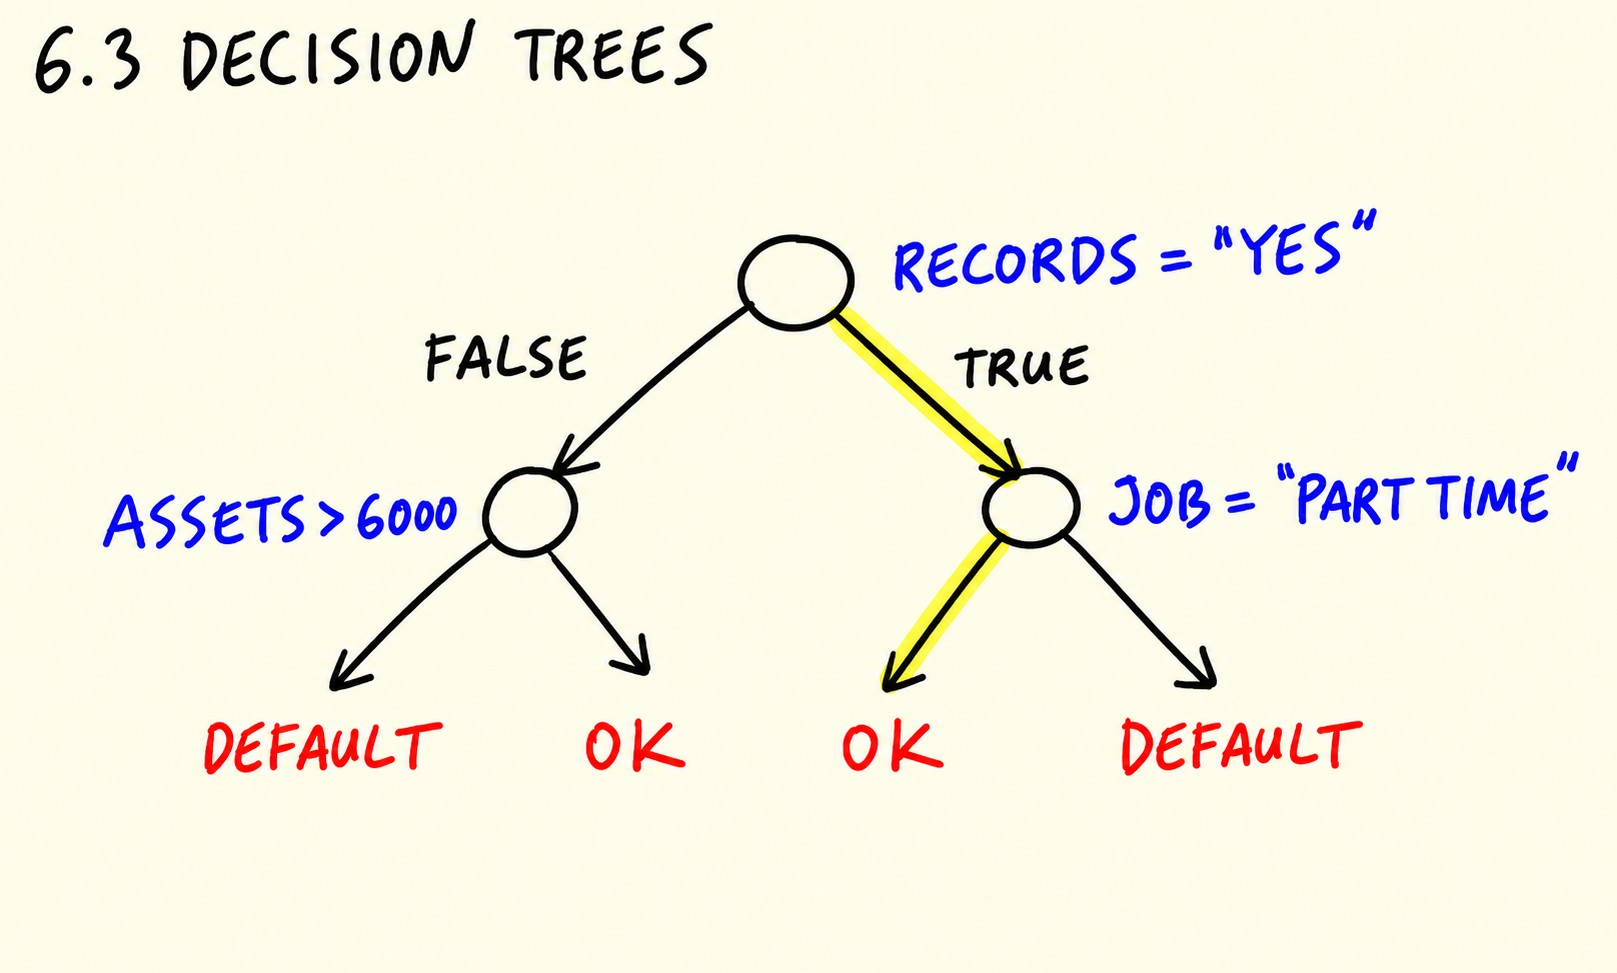

In [ ]:
xi = df_train.iloc[0].to_dict()
assest_risk(xi)

writing rules by hand do not scale. The point of decision tree algo is that it learns these rules from data automatically

## Training a decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [ ]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

In [ ]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

## Overfitting

In [ ]:
y_pred = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_train, y_pred)

1.0 on training but 0.66 on validation: the tree memorized the training data. It learned one specific rule per customer, so on the customers it has seen it's perfect. These rules do not generalize to unseen customers. This is overfitting: memorizing the data but failing to generalize.

The reason is that we let the tree grow without limits, so it became very deep: it kept splitting until every leaf was pure

## Controlling the size of the tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

In [ ]:
y_pred = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print('train', auc)

y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)

Training AUC went down but validation AUC went up. We traded some accuracy on known customers for the ability to generalize.

In [ ]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

A tree with depth of 1, single condition, is called a decision stump. It's not really a tree, just one split, and it's the simplest possible tree.

# Decision Tree learning

## Tree vocab

<lo>
<li> A node contains a condition
<li> Two branches go out of it: one for true and one for false
<li> The node at the top is the root; every node except the leaves is a parent of two other nodes.
<li> The nodes at the bottom are leaves (decision nodes): this is where the tree stops and the prediction is made.
<li> The depth of a tree is the number of levels, the length of the longest path from the root to a leaf.
<lo>

In [ ]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])

In [ ]:
Ts = [0,2000,3000,4000,5000,8000] #Tresholds

In [ ]:
T =40000
df_left = df_example[df_example.assets <= T]
df_right = df_example[df_example.assets > T]

display(df_left)
print(df_left.status.value_counts(normalize=True))
display(df_right)
print(df_right.status.value_counts(normalize=True))

For each side we predict the majority class, the most frequent status. This mistake rate is called misclassification rate, and it is one way of measuring how impure a group is. A pure group contains only one class, zero misclassification rate. We can compute the rates for both sides with value_counts(normalize=True) and avg them, weighted by grop size

In [ ]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000,  500, 'ok'],
    [3000, 2000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])

In [ ]:
thresholds = {
    'assets': [0, 2000, 3000, 4000, 5000, 8000],
    'debt': [500, 1000, 2000]
}

for feature, Ts in thresholds.items():
    print('######')
    print(feature)
    for T in Ts:
        print(T)
        df_left = df_example[df_example[feature] <= T]
        df_right = df_example[df_example[feature] > T]

        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))

        print()
    print('#####################')

## Stopping criteria

After the root is split, the algorithm applies the same procedure recursively to the left and right sides.
<lo>
<li> The group is already pure, the misclassification rate is 0%, no point in splitting further
<li> The tree reached max depth limit
<li> The group is too small to split
<li> The maximum number of leaves was reached
<lo>

# Gradient boosting and XGBoost

Unlike random forest, where trees are trained independently, boosting trains models one by one, each next model fixing the errors of the previous ones. We use XGBoost, the most popular implementation of gradient boosting, to train our first model and to monitor how it learns.

## Boosting vs random forest

In random forest, all the trees are trained in parallel: each tree gets a random subset of features, they do not talk to each other, and their predictions are averaged at the end.

Gradient boosting works sequentially. First train one model and look where it makes errors. Then train the second model on these errors, so it learns to fix the mistakes of the first one. The third model fixes the errors of the second one, and so on. The final prediction combines what all the models in the sequence have learned.

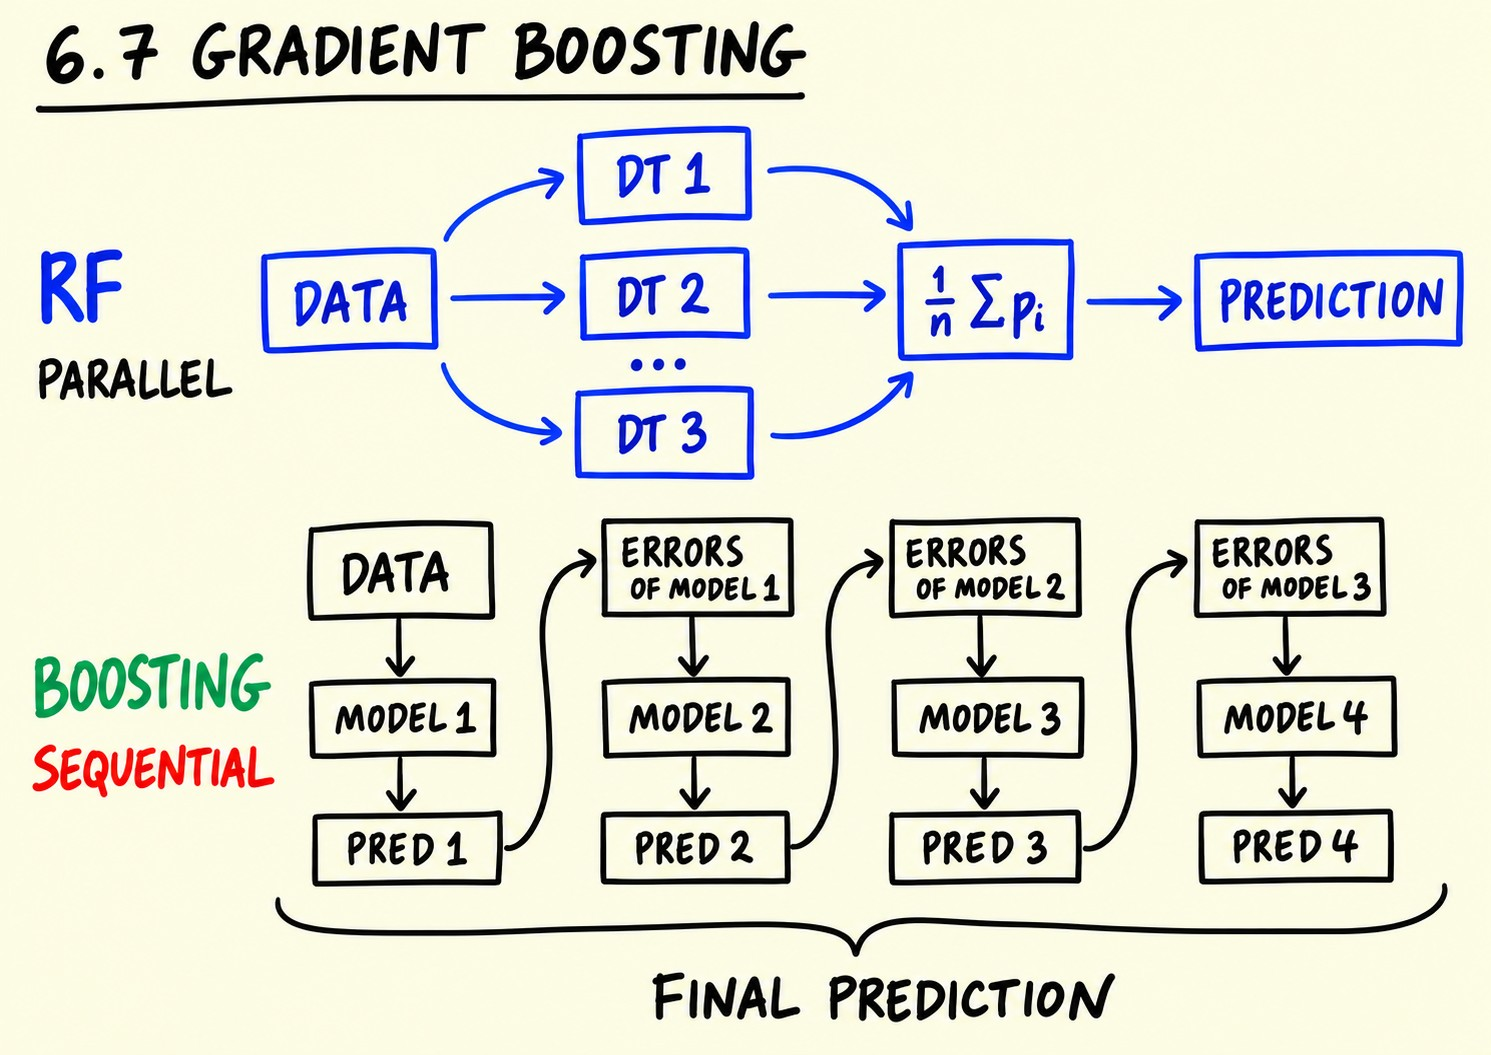

When the models in this sequence are decision trees, the method is called gradient boosting trees:

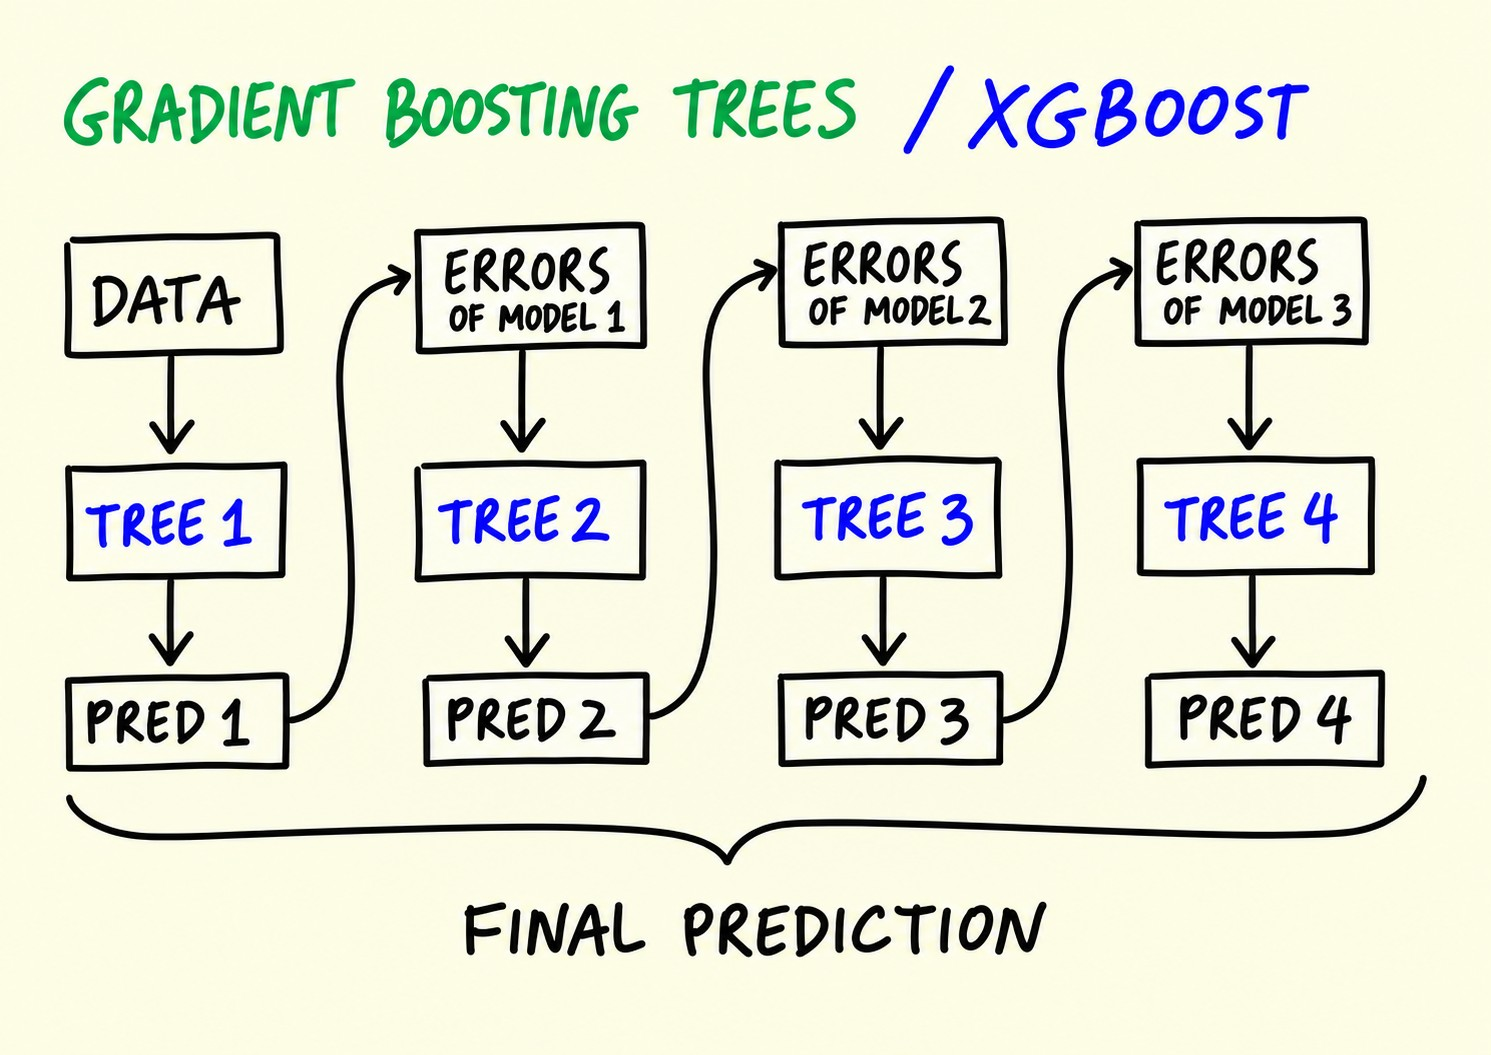

In [ ]:
import xgboost as xgb

XGBoost does not work with numpy arrays directly. Instead, we wrap the data into a special data structure called DMatrix, which is optimized for training XGBoost models.

In [ ]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [ ]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=10)

<lo>
<li> eta is the learning rate, how large the correction each next model applies
<li> max_depth and min_child_weight control the size of the trees
<li> objective is the task we are solving, binary:logistic is binary classification
<lo>

In [ ]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

## Performance monitoring

To watch it learn, we pass a watchlist, a list of datasets to evaluate after each round. By default XGBoost monitors logloss, the metric it optimizes, but that is hard to interpret, so we switch the evaluation metric to AUC.

In [ ]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [ ]:
def train_and_score(params, num_boost_round=200, evals=None):
    """Train and return the per-iteration AUC history as a DataFrame."""
    evals = evals if evals is not None else watchlist
    evals_result = {}

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        evals_result=evals_result,
        verbose_eval=False,
    )

    metric = params.get('eval_metric', 'auc')
    df_results = pd.DataFrame({
        'num_iter': range(num_boost_round),
        'train_auc': evals_result['train'][metric],
        'val_auc': evals_result['val'][metric],
    })
    return model, df_results

In [ ]:
def plot_scores(scores, title=''):
    for key, df_score in scores.items():
        plt.plot(df_score.num_iter, df_score.val_auc, label=key)

    plt.xlabel('boosting round')
    plt.ylabel('validation AUC')
    plt.title(title)
    plt.legend()
    plt.show()


def best_scores(scores):
    return pd.DataFrame(
        [(key, df.val_auc.max(), int(df.val_auc.idxmax())) for key, df in scores.items()],
        columns=['params', 'best_val_auc', 'best_round'],
    ).sort_values('best_val_auc', ascending=False)

In [ ]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model, df_score = train_and_score(xgb_params)

plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.xlabel('boosting round')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [ ]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

# XGBoost parameter tuning

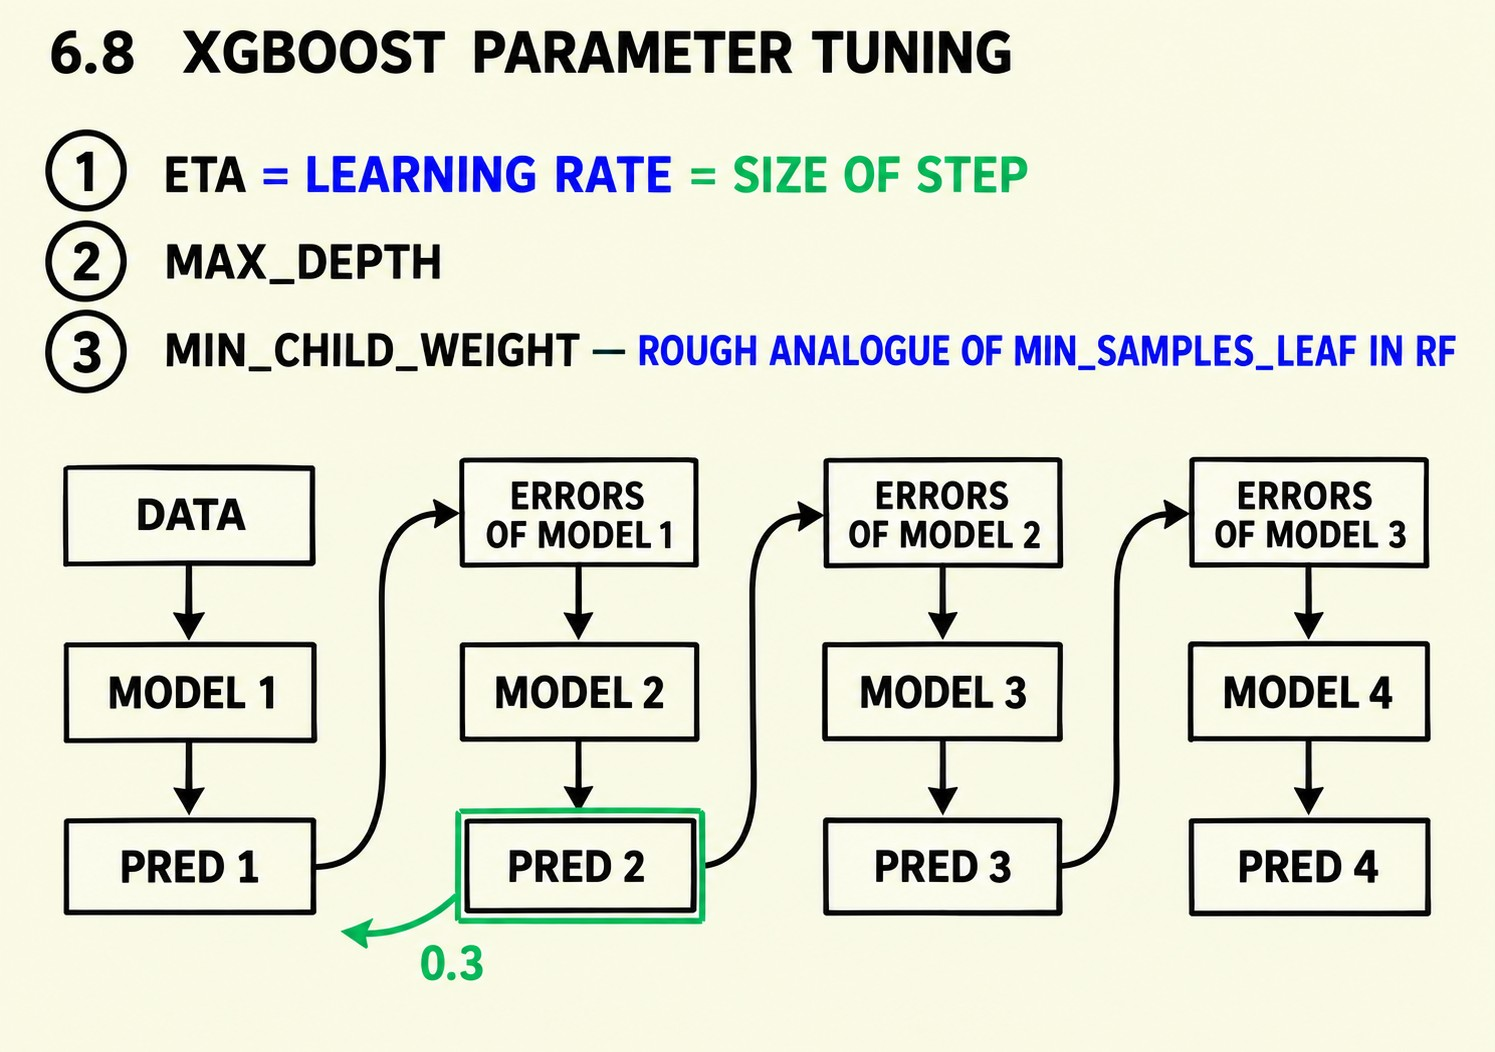

In [ ]:
scores = {}

for eta in [1.0, 0.3, 0.1, 0.05, 0.01]:
    xgb_params['eta'] = eta
    _, df_score = train_and_score(xgb_params)
    scores['eta=%s' % eta] = df_score

plot_scores(scores, 'eta')
best_scores(scores)

In [ ]:
best_eta = float(best_scores(scores).iloc[0]['params'].split('=')[1])
print('best eta:', best_eta)

In [ ]:
scores = {}
xgb_params['eta'] = best_eta

for max_depth in [3, 4, 6, 10]:
    xgb_params['max_depth'] = max_depth
    _, df_score = train_and_score(xgb_params)
    scores['max_depth=%s' % max_depth] = df_score

plot_scores(scores, 'max_depth')
best_scores(scores)

In [ ]:
best_max_depth = int(best_scores(scores).iloc[0]['params'].split('=')[1])
print('best max_depth:', best_max_depth)

In [ ]:
scores = {}
xgb_params['max_depth'] = best_max_depth

for min_child_weight in [1, 10, 30]:
    xgb_params['min_child_weight'] = min_child_weight
    _, df_score = train_and_score(xgb_params)
    scores['min_child_weight=%s' % min_child_weight] = df_score

plot_scores(scores, 'min_child_weight')
best_scores(scores)

In [ ]:
best_row = best_scores(scores).iloc[0]
best_min_child_weight = int(best_row['params'].split('=')[1])
best_num_round = int(best_row['best_round']) + 1

print('best min_child_weight:', best_min_child_weight)
print('best num_boost_round:', best_num_round)


In [ ]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

Other parameters worth knowing about:

subsample - the fraction of the training data each tree sees.
colsample_bytree - the fraction of features each tree sees, like the random feature subsets of random forest.
lambda and alpha - the L2 and L1 regularization terms on the weights.

# Final model

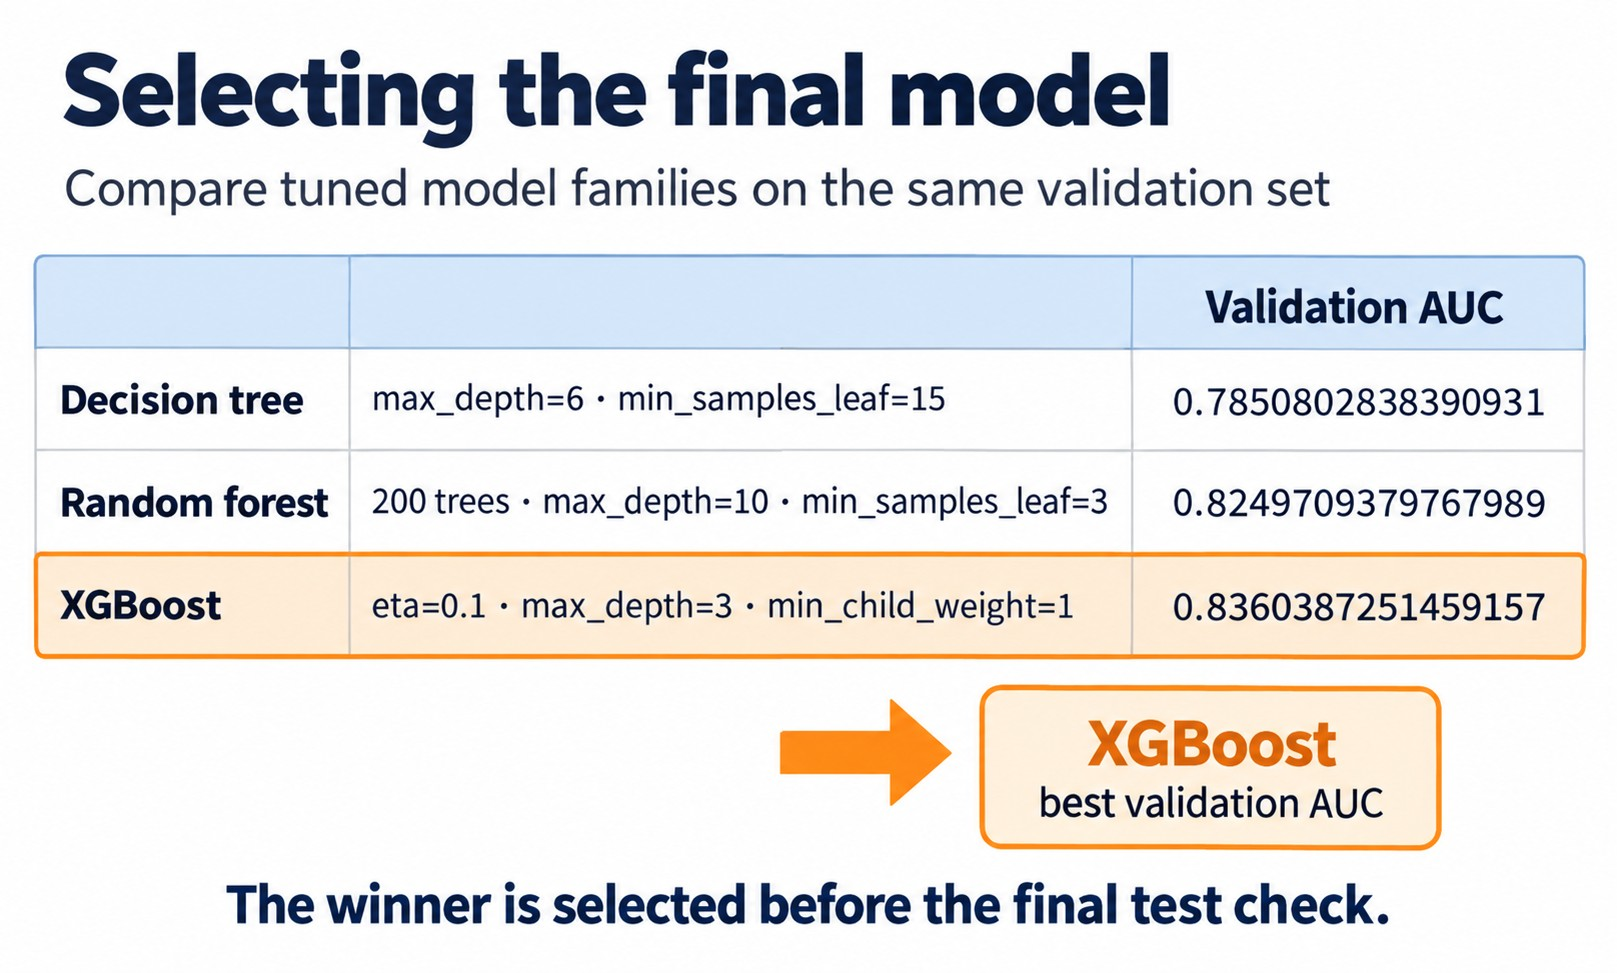

In [ ]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

In [ ]:
y_pred = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=1)
rf.fit(X_train, y_train)

In [ ]:
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

In [ ]:
xgb_params = {'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,}

model = xgb.train(xgb_params, dtrain, num_boost_round=175)

In [ ]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

XGBoost wins with 83%, ahead of random forest at 82% and single decision tree at 78%. this is a typical outcome: boosted trees are very strong on tabular data. The price is that XGBoost has many hyperparams and can overfit quickly.

## Training the final model

In [ ]:
df_full_train = df_full_train.reset_index(drop=True)

y_full_train = (df_full_train.status == 'default').astype(int).values
del df_full_train['status']

In [ ]:
dicts_full_train = df_full_train.fillna(0).to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.fillna(0).to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [ ]:
features = list(dv.get_feature_names_out())

dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)
dtest = xgb.DMatrix(X_test, feature_names=features)

In [ ]:
model = xgb.train(xgb_params, dfulltrain, num_boost_round=best_num_round)

In [ ]:
y_pred = model.predict(dtest)
print('test auc', roc_auc_score(y_test, y_pred))

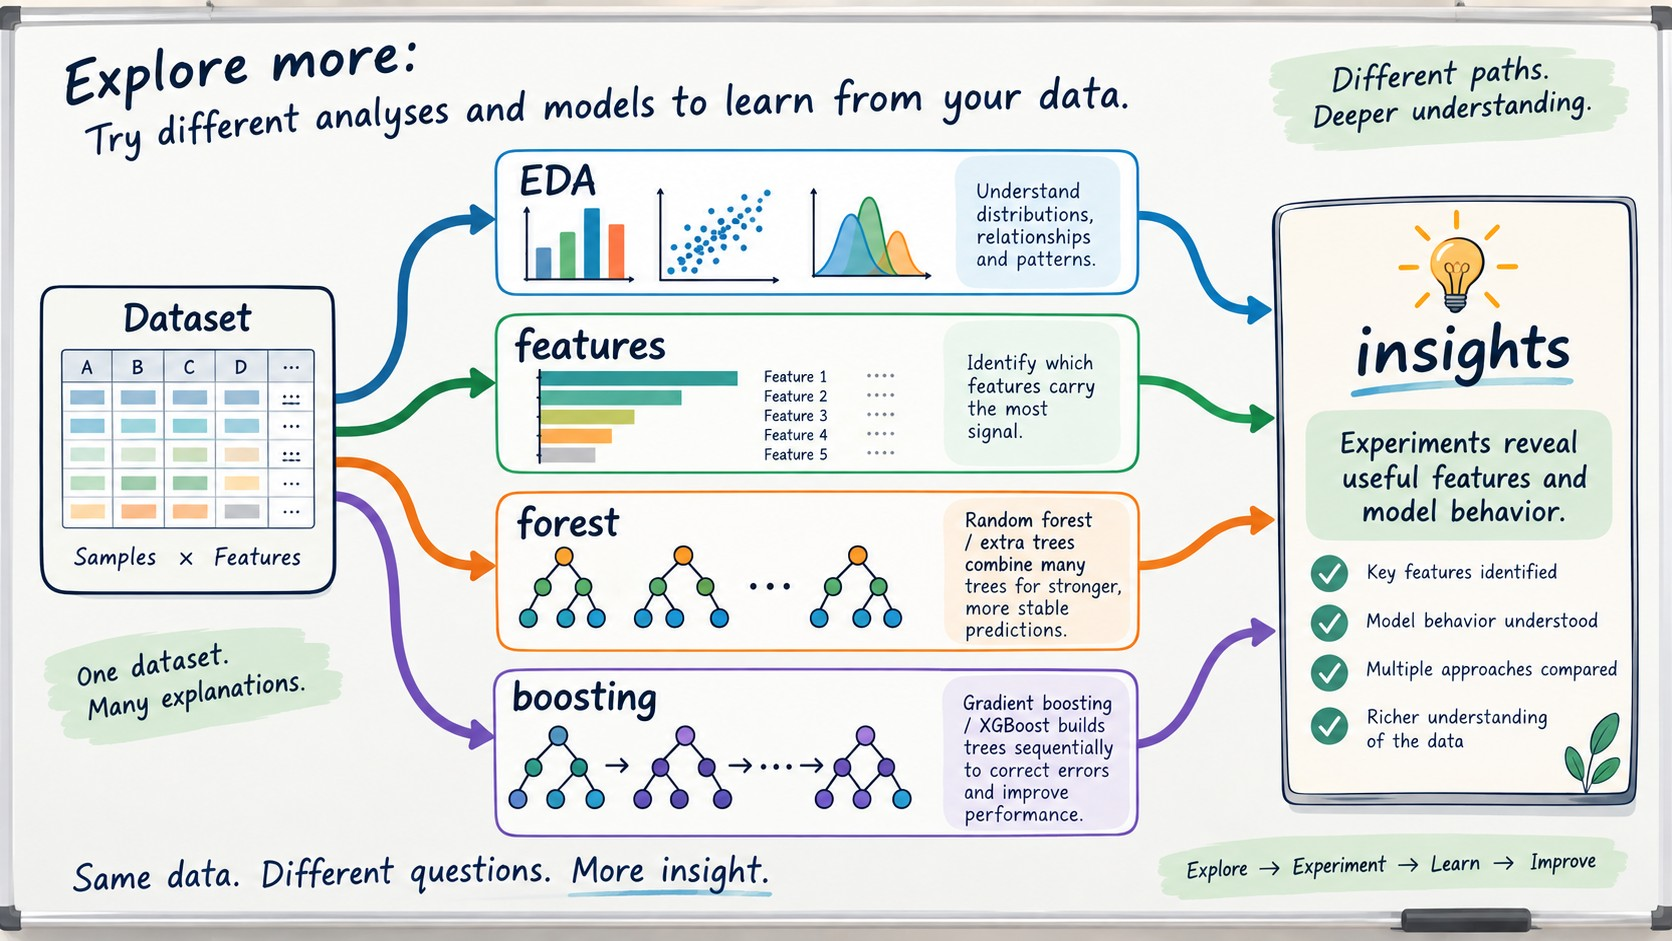

# Explore more

In [ ]:
df = pd.read_csv('CreditScoring.csv')
df = df.copy()
df.columns = df.columns.str.lower()
df.columns

In [ ]:
df['assets'] = df['assets'].replace(99999999, np.nan)

job_values = {1: 'fulltime', 2: 'parttime', 3: 'unemployed'}
df['job'] = df['job'].map(job_values)

def asset_risk(row):
    if pd.isna(row['assets']):
        return 'review'
    if row['job'] == 'parttime':
        return 'default'
    if row['assets'] > 6000:
        return 'low_risk'
    else:
        return 'default'

df['risk_category'] = df.apply(asset_risk, axis=1)

In [ ]:
print("=== 1. DATASET OVERVIEW & MISSING VALUES ===")
print(df.info())
print("\nMissing Values Count:")
print(df[['age', 'job', 'assets']].isna().sum())

print("\n=== 2. NUMERICAL DESCRIPTIVE STATISTICS ===")
print(df[['age', 'assets']].describe().T)

print("\n=== 3. CATEGORICAL FREQUENCY DISTRIBUTION ===")
print("\nJob Distribution:")
print(df['job'].value_counts(normalize=True).round(4) * 100)

print("\nRisk Category Distribution:")
print(df['risk_category'].value_counts(normalize=True).round(4) * 100)

print("\n=== 4. BIVARIATE CROSS-TABULATION (Job vs Risk) ===")
ct = pd.crosstab(df['job'], df['risk_category'], margins=True, margins_name="Total")
print(ct)

print("\n=== 5. ASSET AGGREGATION BY RISK CATEGORY ===")
risk_stats = df.groupby('risk_category')['assets'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(risk_stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='risk_category', y='assets', ax=axes[0, 0],hue='risk_category', palette='Set2')
sns.stripplot(data=df, x='risk_category', y='assets', ax=axes[0, 0], color='black', alpha=0.3, jitter=0.2)
axes[0, 0].set_title('Asset Distribution by Risk Category')
axes[0, 0].set_ylabel('Assets ($)')

sns.countplot(data=df, x='job', hue='risk_category', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Job Type vs. Risk Category')
axes[0, 1].set_xlabel('Job Type')
axes[0, 1].set_ylabel('Count')

sns.histplot(data=df, x='assets', kde=True, ax=axes[1, 0], color='teal', bins=20)
axes[1, 0].set_title('Overall Asset Distribution Density')
axes[1, 0].set_xlabel('Assets ($)')

sns.scatterplot(data=df, x='age', y='assets', hue='risk_category', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Age vs Assets by Risk Category')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Assets ($)')

plt.tight_layout()
plt.savefig('eda_summary_plots.png')
print("\nPlot saved successfully as 'eda_summary_plots.png'.")

In [ ]:
def feature_engineering(df_input):
    df = df_input.copy()

    df['assets_missing'] = df['assets'].isna().astype(int)
    job_asset_medians = df.groupby('job')['assets'].transform('median')
    df['assets_imputed'] = df['assets'].fillna(job_asset_medians)

    df['log_assets'] = np.log1p(df['assets_imputed'])

    df['asset_to_age'] = df['assets_imputed'] / df['age']

    df['is_employed'] = (df['job'] != 'unemployed').astype(int)
    df = pd.get_dummies(df, columns=['job'],prefix='job_type', drop_first=False, dtype=int)
    df['age_group'] = pd.cut(df['age'], bins=[17,30,50,100],labels=['young', 'middle_aged','senior'])
    return df

In [ ]:
df_engineered = feature_engineering(df)

In [ ]:
df_engineered.head()

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
param_grid = {
    "n_estimators": [100,200],
    'max_depth': [None, 10,20],
    'max_features': ['sqrt','log2', 0.5, None],
    'bootstrap': [True, False],
    'min_samples_split': [2, 5],
}

rf = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train,y_train)

In [ ]:
print(f"Optimal Params: {grid_search.best_params_}")
print(f"Optimal CV score: {grid_search.best_score_}")

In [ ]:
res = pd.DataFrame(grid_search.cv_results_)
pivot_summary = res.pivot_table(
    index='param_bootstrap',
    columns='param_max_features',
    values='mean_test_score',
    aggfunc='max',
)
print("\n ROC AUC Matrix: Boostsrap vs Max Features:")
print(pivot_summary)

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_validate

In [ ]:
et_model = ExtraTreesClassifier(
    n_estimators=100, max_depth = 10, min_samples_leaf=2, random_state=42
)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=2, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

et_results = cross_validate(et_model, X_train, y_train, cv=cv, scoring='roc_auc')
rf_results = cross_validate(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(
    f"Extra Trees: Test ACC {et_results['test_score'].mean():.4f} | Fit Time: {et_results['fit_time'].mean():.4f}"
)
print(
    f"Random Forest: Test Acc: {rf_results['test_score'].mean():.4f} | Fit time: {rf_results['fit_time'].mean():.4f}"
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
df_native = df_train.copy()
df_native['assets_missing'] = df_native['assets'].isna().astype(int)
df_native['job'] = df_native['job'].astype('category')
X_native = df_native[['age', 'assets', 'assets_missing', 'job']]

xgb_native = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    missing=np.nan, enable_categorical=True, random_state=42
)

df_imputed = df_train.copy()
df_imputed['assets_missing'] = df_imputed['assets'].isna().astype(int)
job_medians = df_imputed.groupby('job')['assets'].transform('median')
df_imputed['assets'] = df_imputed['assets'].fillna(job_medians)
df_imputed['job'] = df_imputed['job'].astype('category')
X_imputed = df_imputed[['age', 'assets', 'assets_missing', 'job']]

xgb_imputed = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    enable_categorical=True, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score_native  = cross_val_score(xgb_native,  X_native,  y_train, cv=cv, scoring='roc_auc').mean()
score_imputed = cross_val_score(xgb_imputed, X_imputed, y_train, cv=cv, scoring='roc_auc').mean()

print(f"Native NaN CV ROC AUC:     {score_native:.4f}")
print(f"Median Imputed CV ROC AUC: {score_imputed:.4f}")

In [ ]:
subsample=[0.6,0.8,1.0]
colsample=[0.6,0.8,1.0]

res = {}
for ss in subsample:
    for cs in colsample:
        model = XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            subsample=ss,
            colsample_bytree=cs,
            random_state=42,
            eval_metric='logloss',
        )
        score = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
        res[(ss,cs)] = score
        print(f"subsample={ss}, colsample_bytree={cs}: {score:.4f}")
best = max(res.values())
print(f"Best CV ROC AUC: {best:.4f}")

Using GridSearch

In [ ]:
param_grid = {
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

base = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                     random_state=42, eval_metric='logloss')

grid = GridSearchCV(base, param_grid, cv=cv, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best ROC AUC:", grid.best_score_)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb
from xgboost import XGBClassifier

cat = ['home', 'marital', 'records', 'job']
num = ['seniority', 'time', 'age', 'expenses', 'income', 'assets', 'debt', 'amount', 'price']

X_train_df = df_train[cat + num]
X_val_df   = df_val[cat + num]

X_train_enc = pd.get_dummies(X_train_df)
X_val_enc   = pd.get_dummies(X_val_df).reindex(columns=X_train_enc.columns, fill_value=0)

print(X_train_enc.shape, X_val_enc.shape)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_enc, y_train)

rf_imp = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(rf_imp)

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train_enc, y_train)

booster = xgb_model.get_booster()
weight = booster.get_score(importance_type='weight')
gain   = booster.get_score(importance_type='gain')
cover  = booster.get_score(importance_type='cover')

xgb_imp = pd.DataFrame({
    'feature': X_train.columns,
    'weight': [weight.get(f, 0) for f in X_train.columns],
    'gain':   [gain.get(f, 0)   for f in X_train.columns],
    'cover':  [cover.get(f, 0)  for f in X_train.columns],
}).sort_values('gain', ascending=False)

print("=== XGBoost importance (sorted by gain) ===")
print(xgb_imp, "\n")

perm = permutation_importance(rf, X_val_enc, y_val, n_repeats=10,
                              random_state=42, scoring='roc_auc')
perm_imp = pd.DataFrame({
    'feature': X_val_enc.columns,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

print("=== Permutation importance (Random Forest) ===")
print(perm_imp, "\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=rf_imp, x='importance', y='feature', ax=axes[0])
axes[0].set_title('Random Forest')

sns.barplot(data=xgb_imp, x='gain', y='feature', ax=axes[1])
axes[1].set_title('XGBoost (gain)')

sns.barplot(data=perm_imp, x='importance', y='feature', ax=axes[2])
axes[2].set_title('Permutation (RF)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train_enc, y_train)
pred = dt.predict(X_val_enc)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_enc, y_train)
pred = rf.predict(X_val_enc)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective='reg:squarederror',   # ﷿﷿﷿ the regression objective
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train_enc, y_train)
pred = xgb_model.predict(X_val_enc)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae  = mean_absolute_error(y_val, pred)
r2   = r2_score(y_val, pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R﷿﷿:   {r2:.4f}")

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train_enc, y_train, cv=5,
                         scoring='neg_root_mean_squared_error')
print(-scores.mean())